In [1]:
# Setup (standalone run): imports + load Task 1 output
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/df_task1.csv")
print("Loaded:", df.shape)

Loaded: (7043, 20)


## Task 3: Feature Selection

**Method:** bivariate relevance analysis — churn rate per category + numeric means by churn + correlation with the churn flag, combined with domain knowledge.

**Why this way:**
- Churn is binary, so the most direct signal is: how much does the churn rate change across a feature's values?
- Features with big gaps (e.g. `Month-to-month` 43% vs `Two year` 3%) are strong predictors; features with flat rates (e.g. `gender`) carry almost no signal.
- This analysis is done on the full data before modeling; the selected drivers will guide Task 4 (model choice) and interpretation in Task 6.
- **Selection decision:** drop `gender` (Female 26.92% vs Male 26.16% churn — gap ~0.76pp, no signal). All other features are kept for modeling.

In [2]:
# Task 3a: numeric features vs churn
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)
print("Mean of numeric features by Churn:")
print(df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean().round(2).to_string())
print("\nCorrelation of numerics with churn flag:")
print(df[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "ChurnFlag"]].corr(numeric_only=True)["ChurnFlag"].round(4).to_string())

Mean of numeric features by Churn:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.57           61.27       2549.91
Yes     17.98           74.44       1531.80

Correlation of numerics with churn flag:
tenure           -0.3522
MonthlyCharges    0.1934
TotalCharges     -0.1983
SeniorCitizen     0.1509
ChurnFlag         1.0000


In [3]:
# Task 3b: churn rate (%) per category — big gaps = strong predictors
for c in ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling", "TechSupport", "OnlineSecurity", "Partner", "Dependents", "gender"]:
    print(f"== churn % by {c} ==")
    print((df.groupby(c)["ChurnFlag"].mean().round(4) * 100).to_string())
    print()

== churn % by Contract ==
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83

== churn % by InternetService ==
InternetService
DSL            18.96
Fiber optic    41.89
No              7.40

== churn % by PaymentMethod ==
PaymentMethod
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11

== churn % by PaperlessBilling ==
PaperlessBilling
No     16.33
Yes    33.57

== churn % by TechSupport ==
TechSupport
No                     41.64
No internet service     7.40
Yes                    15.17

== churn % by OnlineSecurity ==
OnlineSecurity
No                     41.77
No internet service     7.40
Yes                    14.61

== churn % by Partner ==
Partner
No     32.96
Yes    19.66

== churn % by Dependents ==
Dependents
No     31.28
Yes    15.45

== churn % by gender ==
gender
Female    26.92
Male      26.16



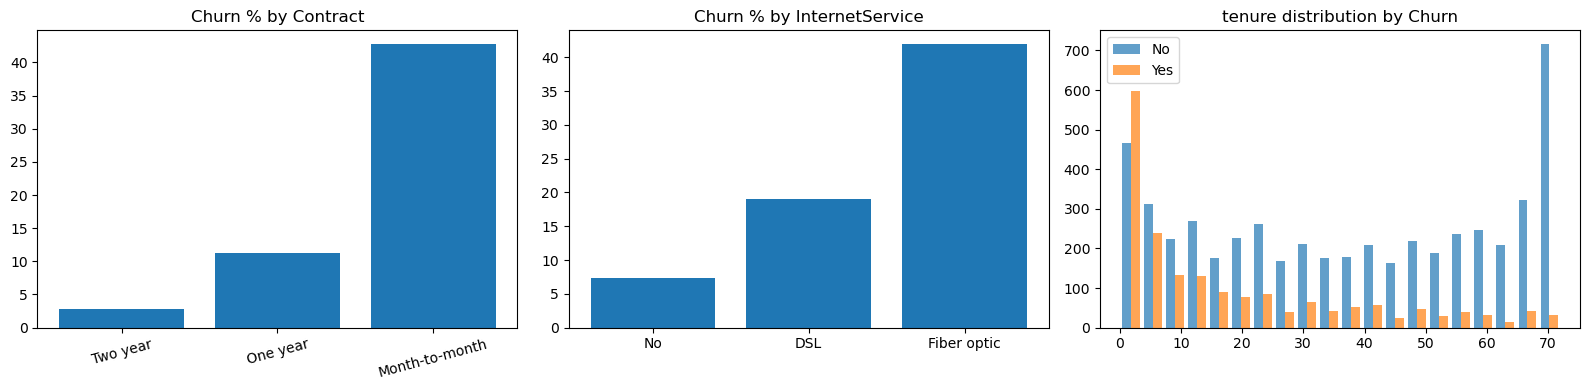

In [4]:
# Task 3c: visualize top drivers
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
r = df.groupby("Contract")["ChurnFlag"].mean().sort_values() * 100
axes[0].bar(r.index, r.values)
axes[0].set_title("Churn % by Contract")
axes[0].tick_params(axis="x", rotation=15)
r2 = df.groupby("InternetService")["ChurnFlag"].mean().sort_values() * 100
axes[1].bar(r2.index, r2.values)
axes[1].set_title("Churn % by InternetService")
axes[2].hist([df[df["Churn"] == "No"]["tenure"], df[df["Churn"] == "Yes"]["tenure"]], label=["No", "Yes"], bins=20, alpha=0.7)
axes[2].legend()
axes[2].set_title("tenure distribution by Churn")
plt.tight_layout()
plt.show()

In [5]:
# Export end-state (with ChurnFlag) for reference
import os
os.makedirs("data", exist_ok=True)
df.to_csv("data/df_task3.csv", index=False)
print("Saved data/df_task3.csv:", df.shape)

Saved data/df_task3.csv: (7043, 21)
